# Food Security Assessment

This lesson assesses vegetation and climate stress for an approximate
Marsabit County AOI using vegetation condition, temperature condition,
rainfall anomaly, NDVI trend, surface water, terrain, and land cover.

**Learning objectives**

- explain VCI, TCI, and the composite stress score;
- choose a long-term reference period;
- interpret risk classes and vegetation-health indicators;
- visualize NDVI and rainfall without mixing incompatible scales.


## 1. Prepare the notebook session

This cell imports the tools used throughout the lesson and loads configuration
from a local `.env` file. The Earth Engine project identifier is configuration,
not analysis data, so it is kept outside the notebook.

Before running the notebook:

1. copy `.env.example` to `.env`;
2. replace the placeholder with your Google Earth Engine project ID;
3. run `earthengine authenticate` once in a terminal;
4. select the **Climate Change Workflows** kernel.

The `%matplotlib inline` backend renders figures directly below each plotting cell.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

WORKSPACE = Path.cwd()
if not (WORKSPACE / ".venv").exists() and (WORKSPACE.parent / ".venv").exists():
    WORKSPACE = WORKSPACE.parent

load_dotenv(WORKSPACE / ".env")
GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError("Create .env from .env.example and set GEE_PROJECT.")

OUTPUT_DIR = WORKSPACE / "outputs"
REPORT_DIR = WORKSPACE / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Workspace:", WORKSPACE)
print("Earth Engine project configured:", bool(GEE_PROJECT))


Workspace: /home/odero-george/workspace/climate-change
Earth Engine project configured: True


## 2. Inspect the package registry

The registry is the package's catalogue of supported analyses. It documents the
recommended date range, dependent variable, input variables, and selectable models.
Inspecting it before running an analysis helps us choose scientifically sensible
parameters instead of treating the model as a black box.


In [2]:
info = USE_CASE_REGISTRY["food_security"]
print(info.name)
print("\nPurpose:", info.description)
print("\nPredicted variable:", info.dependent_variable)
print("\nDate guidance:", info.date_guidance)
print("\nAvailable models:")
for option in info.model_options:
    marker = " (recommended)" if option.recommended else ""
    print(f"  - {option.id}: {option.label}{marker} — {option.note}")

Food Security Assessment

Purpose: This tool predicts crop yields and identifies areas at risk of food shortages by analysing vegetation health, rainfall, temperature, and soil moisture using satellite data. It shows where harvests are likely to be poor and flags food-insecure zones.

Predicted variable: Crop yield (tonnes/ha) or food insecurity risk class

Date guidance: Select a full growing season (at least 3 months). Long rains: Mar–May. Short rains: Oct–Dec.

Available models:
  - rf: Random Forest (recommended) — Fast · interpretable
  - xgboost: XGBoost — High accuracy · longer run
  - ensemble: Ensemble (RF + XGBoost) — Best overall · slower


## 3. Mathematical/Scientific model

Vegetation Condition Index compares current NDVI with its historical range:

$$
\mathrm{VCI}
= 100\frac{\mathrm{NDVI}-\mathrm{NDVI}_{\min}}
{\mathrm{NDVI}_{\max}-\mathrm{NDVI}_{\min}}
$$

Temperature Condition Index similarly expresses thermal stress. Vegetation
Health Index combines the two:

$$
\mathrm{VHI}=0.5\,\mathrm{VCI}+0.5\,\mathrm{TCI}
$$

The package constructs a food-stress score from normalized stress terms:

$$
S = 0.40S_{\mathrm{VCI}} + 0.25S_{\mathrm{TCI}}
+ 0.20S_{\mathrm{rain}} + 0.15S_{\mathrm{NDVI\ trend}}
$$

Higher $S$ indicates greater food-security pressure. These are remote-sensing
proxies and should be combined with market, nutrition, livelihood, and field data.

## 4. Configure the study period and baseline

The study spans six years, while the long-term baseline begins in 2001.
The baseline is essential because VCI and rainfall anomaly are relative measures.
A 1 km scale is appropriate for the MODIS and CHIRPS inputs used here.


In [3]:
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [36.00, 1.00], [38.20, 1.00], [38.20, 3.70],
        [36.00, 3.70], [36.00, 1.00],
    ]],
}

analysis_args = {
    "module": "food_security",
    "aoi_geojson": aoi,
    "start_date": "2018-01-01",
    "end_date": "2023-12-31",
    "country": "Kenya",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "rf",
        "lt_baseline_start": "2001-01-01",
        "s2_start": "2020-01-01",
        "n_pixels": 3000,
        "scale": 1000,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "marsabit_food_security",
    },
}
analysis_args


{'module': 'food_security',
 'aoi_geojson': {'type': 'Polygon',
  'coordinates': [[[36.0, 1.0],
    [38.2, 1.0],
    [38.2, 3.7],
    [36.0, 3.7],
    [36.0, 1.0]]]},
 'start_date': '2018-01-01',
 'end_date': '2023-12-31',
 'country': 'Kenya',
 'gee_project': 'parallelprocessing-433914',
 'extra_params': {'model_type': 'rf',
  'lt_baseline_start': '2001-01-01',
  's2_start': '2020-01-01',
  'n_pixels': 3000,
  'scale': 1000,
  'output_dir': '/home/odero-george/workspace/climate-change/outputs',
  'prefix': 'marsabit_food_security'}}

## 5. Run the analysis

`run_analysis` is asynchronous because data retrieval and model execution may be
long-running operations. Jupyter supports top-level `await`, so no explicit event
loop is required here.

The first run may take several minutes. Runtime depends on AOI size, temporal
coverage, Earth Engine quota, sampling resolution, and model choice.


In [4]:
output = await run_analysis(**analysis_args)
print("Analysis complete:", output.module)

2026-07-03 16:47:34,411 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/odero-george/workspace/climate-change-workflows/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45851 instead
  warnings.warn(
2026-07-03 16:47:34,594 - distributed.scheduler - INFO - State start
2026-07-03 16:47:34,599 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:35229
2026-07-03 16:47:34,600 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:45851/status
2026-07-03 16:47:34,601 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-07-03 16:47:34,619 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44579'
2026-07-03 16:47:34,622 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.

Analysis complete: food_security


## 6. Inspect the common output contract

Every use case returns an `AnalysisOutput` object with the same top-level fields:

- `stats`: summary indicators suitable for dashboards and reports;
- `charts`: structured time-series and distribution data;
- `geojson`: spatial features for a web map or GIS;
- `raster_path`: generated Cloud-Optimized GeoTIFF path(s), when available;
- `shap`: feature-importance information for supported models;
- `metadata`: model, period, country, and optional report information.

The internal keys of `stats` and `charts` remain specific to each scientific domain.


In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON feature count:", len(output.geojson.get("features", [])))
print("Chart payloads:", sorted(output.charts))
print("Metadata:", output.metadata)

pd.Series(output.stats, name="value").to_frame()

Module: food_security
Raster output: {'food_security_risk': '/home/odero-george/workspace/climate-change/outputs/marsabit_food_security_food_security_risk.tif'}
GeoJSON feature count: 3498
Chart payloads: ['indices', 'model_performance', 'riskDist', 'shap', 'timeSeries']
Metadata: {'model': 'rf', 'country': 'Kenya', 'start_date': '2018-01-01', 'end_date': '2023-12-31', 'raster': {'food_security_risk': '/home/odero-george/workspace/climate-change/outputs/marsabit_food_security_food_security_risk.tif'}, 'spatial_resolution_m': 1000, 'n_pixels_sampled': 3000}


,value
model_type,rf
n_pixels_sampled,2838
rf_cv_f1,0.9555
rf_f1,0.9406
rf_accuracy,0.9401
xgb_cv_f1,0.956
xgb_f1,0.9419
xgb_accuracy,0.9419
ensemble_f1,0.942
selected_f1,0.9406


## 7. Visualize risk, NDVI, and rainfall

NDVI is unitless and typically lies between $-1$ and $1$, while rainfall is
measured in millimetres. Putting both on one y-axis makes NDVI appear constant.
This plot therefore uses two y-axes and adds an NDVI trend:

$$
\mathrm{NDVI}_t = \beta_0 + \beta_1 t + \varepsilon_t
$$

The annualized slope is $12\beta_1$ when $t$ is measured in months.


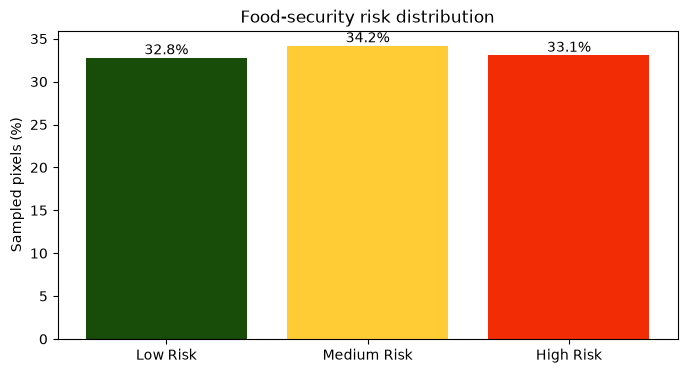

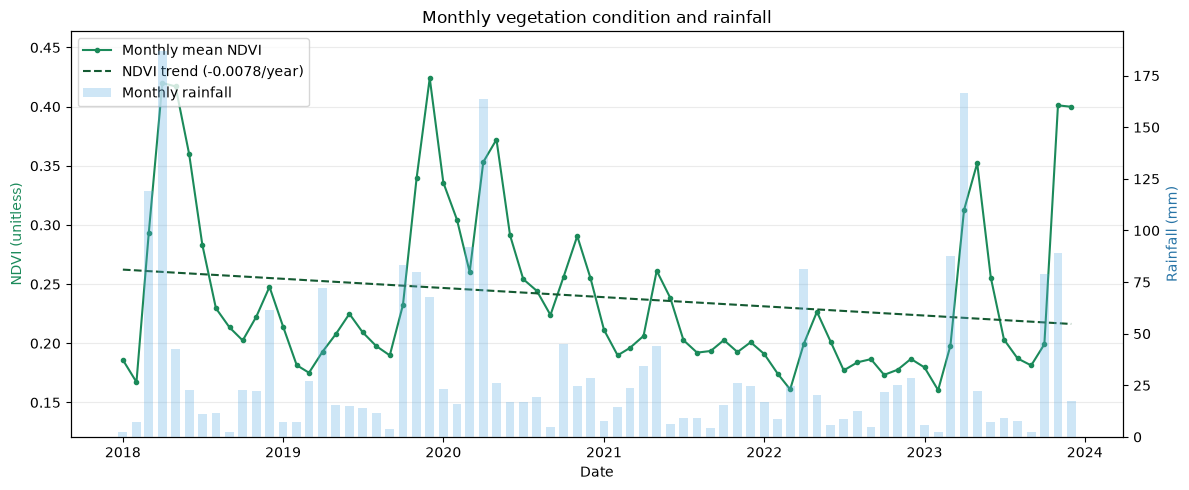

In [6]:
risk = output.charts.get("riskDist", {})
if risk.get("labels"):
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(risk["labels"], risk["data"], color=risk.get("colors"))
    ax.bar_label(bars, fmt="%.1f%%")
    ax.set_ylabel("Sampled pixels (%)")
    ax.set_title("Food-security risk distribution")
    plt.show()

series = output.charts.get("timeSeries", {})
datasets = {d["label"]: d["data"] for d in series.get("datasets", [])}
dates = pd.to_datetime(series.get("labels", []))
ndvi = np.asarray(datasets.get("NDVI", []), dtype=float)
rain = np.asarray(datasets.get("Monthly rain (mm)", []), dtype=float)

if len(dates):
    fig, ndvi_ax = plt.subplots(figsize=(12, 5))
    rain_ax = ndvi_ax.twinx()
    months = np.arange(len(dates), dtype=float)

    if ndvi.size:
        ndvi_ax.plot(dates, ndvi, color="#1B8A5A", marker="o",
                     markersize=3, label="Monthly mean NDVI")
        valid = np.isfinite(ndvi)
        if valid.sum() >= 2:
            slope, intercept = np.polyfit(months[valid], ndvi[valid], 1)
            ndvi_ax.plot(dates, intercept + slope * months, "--",
                         color="#145A32",
                         label=f"NDVI trend ({slope * 12:+.4f}/year)")
        finite = ndvi[valid]
        padding = max(0.03, np.ptp(finite) * 0.15)
        ndvi_ax.set_ylim(max(-1, finite.min() - padding), min(1, finite.max() + padding))

    if rain.size:
        rain_ax.bar(dates, rain, width=20, color="#5DADE2", alpha=0.3,
                    label="Monthly rainfall")

    ndvi_ax.set_ylabel("NDVI (unitless)", color="#1B8A5A")
    rain_ax.set_ylabel("Rainfall (mm)", color="#2874A6")
    ndvi_ax.set_xlabel("Date")
    ndvi_ax.set_title("Monthly vegetation condition and rainfall")
    ndvi_ax.xaxis.set_major_locator(mdates.YearLocator())
    ndvi_ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    h1, l1 = ndvi_ax.get_legend_handles_labels()
    h2, l2 = rain_ax.get_legend_handles_labels()
    ndvi_ax.legend(h1 + h2, l1 + l2, loc="upper left")
    ndvi_ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


### 7b. Population exposure

The IPC (food-security phase classification) explicitly reports both the
proportion and the total population in each severity phase — total counts,
not just area shares, are what drive food-aid allocation. Alongside
`riskDist`'s percentage-of-sampled-pixels view, the pipeline performs a
raster zonal sum of WorldPop population counts against the food-security
risk classification:

- `stats['total_population']`: population inside the AOI covered by the
  risk raster;
- `stats['population_affected']`: population in **Medium Risk + High Risk**
  zones (`FOOD_SECURITY_AT_RISK_LABELS`);
- `riskDist['data_population']`: population per class, parallel to the
  existing percentage `data` array.

Population fetch is best-effort — this enrichment is simply absent if
WorldPop could not be fetched for this AOI/year.


In [ ]:
total_population = output.stats.get("total_population")
population_affected = output.stats.get("population_affected")

if total_population is not None:
    print(f"Total population in AOI: {total_population:,.0f}")
    print(
        f"Population in Medium/High food-insecurity zones: {population_affected:,.0f} "
        f"({population_affected / total_population:.1%})"
    )

    risk = output.charts.get("riskDist", {})
    pop_data = risk.get("data_population")
    if pop_data:
        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(risk["labels"], pop_data, color=risk.get("colors"))
        ax.bar_label(bars, fmt="%.0f")
        ax.set_ylabel("Population")
        ax.set_title("Population exposed by food-security risk class")
        plt.show()
else:
    print("Population data was not available for this AOI/year.")


## 8. Locate spatial artifacts

The analysis may produce GeoJSON features and one or more Cloud-Optimized GeoTIFF
files. GeoJSON is convenient for APIs and interactive maps, while COGs preserve
continuous raster coverage for GIS software and cloud-native access.

The following cell reports the artifacts without attempting to display a large
raster inside the notebook.


In [7]:
print("GeoJSON type:", output.geojson.get("type"))
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Raster path(s):", output.raster_path)

if output.raster_path:
    paths = (
        output.raster_path.values()
        if isinstance(output.raster_path, dict)
        else [output.raster_path]
    )
    for path in paths:
        artifact = Path(path)
        print(f"{artifact.name}: exists={artifact.exists()}")


GeoJSON type: FeatureCollection
GeoJSON features: 3498
Raster path(s): {'food_security_risk': '/home/odero-george/workspace/climate-change/outputs/marsabit_food_security_food_security_risk.tif'}
marsabit_food_security_food_security_risk.tif: exists=True


## 9. Optional: generate a PDF report

Setting `GENERATE_REPORT` to `True` reruns the same request and asks the package to
assemble a PDF containing metadata, statistics, charts, interpretation text, and
available map content. Keep it `False` during exploration to avoid an unnecessary
second model run.


In [8]:
GENERATE_REPORT = True

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change/reports/food_security_20260703_135013.pdf
